# 03 — Hazard: GMPE-Based Ground Motion

**Purpose:** Compute intensity measures at bridge sites using the BSSA21
Ground Motion Prediction Equation, and compare against ShakeMap values.

## Input Files

| File | Format | Description |
|------|--------|-------------|
| `config.yaml` | YAML | IM type (SA10), region bounds |
| `data/CA24.txt` | Fixed-width text (NBI) | Bridge locations for distance calculation |
| `data/grid.xml` | XML (ShakeMap) | ShakeMap grid for comparison |
| `data/vs30/california_vs30.npz` | NumPy compressed | USGS Vs30 grid for site effects |

## Outputs (in-memory)

| Object | Type | Description |
|--------|------|-------------|
| `nbi["sa_gmpe"]` | `pd.Series` (float) | BSSA21 median Sa(1.0s) in g at each bridge |
| `nbi["sigma_gmpe"]` | `pd.Series` (float) | Total aleatory sigma (ln units) |
| `nbi["sa_shakemap"]` | `pd.Series` (float) | ShakeMap-interpolated Sa for comparison |

## Expected Plots

- **Scatter plot** — GMPE predicted vs ShakeMap interpolated Sa(1.0s), with 1:1 line, r and mean ratio annotations

**Key concepts:** GMPE (Ground Motion Prediction Equation), Joyner-Boore distance,
Vs30 site effects, aleatory uncertainty, point-source approximation

## Imports & Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import load_config, IM_COLUMN_MAP
from src.data_loader import load_shakemap, load_nbi, classify_nbi_to_hazus
from src.interpolation import interpolate_im
from src.hazard import haversine_distance_km, EarthquakeScenario
from src.gmpe_base import get_gmpe, IM_TYPE_TO_PERIOD
import src.gmpe_bssa21  # Register BSSA21 model
from src.vs30_provider import Vs30Provider, enrich_bridges_with_vs30

pd.set_option("display.max_columns", 20)
%matplotlib inline

## Step 1: Define Earthquake Scenario

In [2]:
# Northridge 1994 earthquake parameters
scenario = EarthquakeScenario(
    Mw=6.7,
    lat=34.213,
    lon=-118.537,
    depth_km=18.4,
    fault_type="reverse",
)

print(f"Earthquake: Mw {scenario.Mw}")
print(f"Location:   ({scenario.lat}, {scenario.lon})")
print(f"Depth:      {scenario.depth_km} km")
print(f"Fault type: {scenario.fault_type}")

Earthquake: Mw 6.7
Location:   (34.213, -118.537)
Depth:      18.4 km
Fault type: reverse


## Step 2: Load Bridges & Vs30

**Input:** `data/CA24.txt` + `data/vs30/california_vs30.npz` (cached USGS Global Hybrid Vs30 Map).
**Output:** `nbi` DataFrame with added `vs30` column (float, m/s). Expected range: ~206–827 m/s.

In [3]:
cfg = load_config(PROJECT_ROOT / "config.yaml")
nbi = load_nbi(PROJECT_ROOT / "data" / "CA24.txt", northridge_bbox=cfg.region)
nbi = classify_nbi_to_hazus(nbi)

# Enrich with Vs30 from USGS global grid
nbi = enrich_bridges_with_vs30(nbi)
print(f"Bridges: {len(nbi)}")
print(f"Vs30 range: {nbi['vs30'].min():.0f} – {nbi['vs30'].max():.0f} m/s")
print(f"Vs30 mean:  {nbi['vs30'].mean():.0f} m/s")

Bridges: 2953
Vs30 range: 206 – 827 m/s
Vs30 mean:  352 m/s


## Step 3: Compute BSSA21 Sa(1.0s) at Each Bridge

For each bridge: compute R_JB via haversine distance (point-source approximation),
then predict Sa(1.0s) and sigma using BSSA21 with site-specific Vs30.

**Output:** `sa_gmpe` array (2953,) in g, `sigma_gmpe` array in ln units.
**Expected range:** ~0.03–0.62 g (lower than ShakeMap due to point-source bias).

In [4]:
gmpe = get_gmpe("bssa21")
period = IM_TYPE_TO_PERIOD[cfg.im_type]  # 1.0 for SA10
print(f"GMPE: {gmpe.name}, Period: {period}s")

sa_gmpe = np.zeros(len(nbi))
sigma_gmpe = np.zeros(len(nbi))

for i, (_, bridge) in enumerate(nbi.iterrows()):
    r_jb = haversine_distance_km(
        scenario.lat, scenario.lon,
        bridge["latitude"], bridge["longitude"],
    )
    median, sigma = gmpe.compute(
        Mw=scenario.Mw,
        R_JB=r_jb,
        Vs30=bridge["vs30"],
        fault_type=scenario.fault_type,
        period=period,
    )
    sa_gmpe[i] = median
    sigma_gmpe[i] = sigma

nbi["sa_gmpe"] = sa_gmpe
nbi["sigma_gmpe"] = sigma_gmpe

print(f"\nGMPE Sa({period}s) statistics:")
print(f"  Min:  {sa_gmpe.min():.4f} g")
print(f"  Max:  {sa_gmpe.max():.4f} g")
print(f"  Mean: {sa_gmpe.mean():.4f} g")

GMPE: bssa21, Period: 1.0s

GMPE Sa(1.0s) statistics:
  Min:  0.0311 g
  Max:  0.6177 g
  Mean: 0.1473 g


## Step 4: Compare GMPE vs ShakeMap

**Expected display:** 15-row styled table with structure_number, lat, lon, vs30, sa_shakemap, sa_gmpe, sigma_gmpe. The GMPE generally under-predicts near-fault sites relative to ShakeMap.

In [5]:
# Get ShakeMap values for comparison
grid = load_shakemap(PROJECT_ROOT / "data" / "grid.xml")
im_col = IM_COLUMN_MAP.get(cfg.im_type, "PSA10")

sa_sm = interpolate_im(
    grid["LAT"].values, grid["LON"].values, grid[im_col].values,
    nbi["latitude"].values, nbi["longitude"].values,
    method="nearest",
)
nbi["sa_shakemap"] = sa_sm

# Display comparison table
display(
    nbi[["structure_number", "latitude", "longitude",
         "vs30", "sa_shakemap", "sa_gmpe", "sigma_gmpe"]]
    .head(15)
    .style.format({"sa_shakemap": "{:.4f}", "sa_gmpe": "{:.4f}",
                   "sigma_gmpe": "{:.3f}", "vs30": "{:.0f}"})
)

,structure_number,latitude,longitude,vs30,sa_shakemap,sa_gmpe,sigma_gmpe
0,52 0036,34.400708,-118.827000,339,0.3974,0.1128,0.692
1,52 0037,34.408781,-118.787797,345,0.3533,0.1181,0.692
2,52 0046,34.143069,-118.849192,486,0.2087,0.0921,0.692
3,52 0237,34.177492,-118.876247,462,0.2727,0.0915,0.692
4,52 0268E,34.157158,-118.825219,350,0.2873,0.1340,0.692
5,52 0273,34.166164,-118.837600,344,0.2929,0.1318,0.692
6,52 0274,34.171808,-118.846039,359,0.2415,0.1247,0.692
7,52 0282,34.278867,-118.662336,490,0.5431,0.1838,0.692
8,52 0283,34.268092,-118.635794,567,0.5065,0.1913,0.692
9,52 0299,34.281439,-118.709178,370,0.7572,0.1886,0.692


## Step 5: Scatter Plot — GMPE vs ShakeMap

**Expected plot:** 7×7 inch scatter plot. X-axis = ShakeMap Sa (g), Y-axis = BSSA21 Sa (g). Dashed 1:1 line. Annotation box shows correlation (r ≈ 0.74) and mean ratio. Points below the 1:1 line indicate GMPE under-prediction.

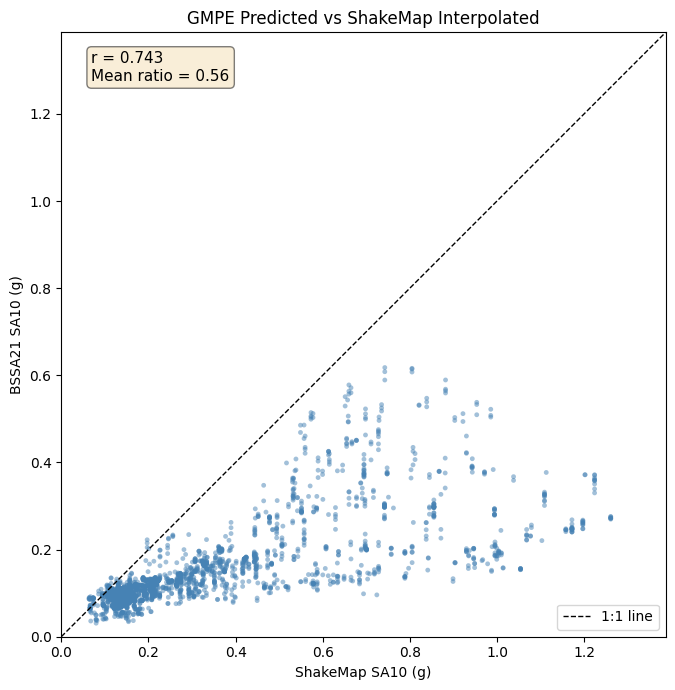

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(sa_sm, sa_gmpe, s=12, alpha=0.5, c="steelblue", edgecolors="none")

# 1:1 line
lim = max(sa_sm.max(), sa_gmpe.max()) * 1.1
ax.plot([0, lim], [0, lim], "k--", lw=1, label="1:1 line")

# Statistics
ratio = sa_gmpe / np.where(sa_sm > 0, sa_sm, np.nan)
r = np.corrcoef(sa_sm, sa_gmpe)[0, 1]
ax.text(0.05, 0.92, f"r = {r:.3f}\nMean ratio = {np.nanmean(ratio):.2f}",
        transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

ax.set_xlabel(f"ShakeMap {cfg.im_type} (g)")
ax.set_ylabel(f"BSSA21 {cfg.im_type} (g)")
ax.set_title("GMPE Predicted vs ShakeMap Interpolated")
ax.legend()
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Point-Source Limitation

The GMPE uses epicentral distance as a proxy for Joyner-Boore distance (R_JB).
This **point-source approximation** is a known limitation:

- For near-source sites, R_JB (closest distance to rupture plane) can be
  significantly less than epicentral distance
- This leads to **under-prediction of IM** at sites close to the fault
  but far from the epicenter
- The effect is most pronounced for large earthquakes (Mw > 6.5) with
  extended rupture areas
- For Northridge (Mw 6.7, rupture ~18 km), the error can be 30–50% at
  sites directly above the rupture but offset from the epicenter

A finite-fault model would improve predictions but requires additional
rupture geometry information.

## Summary

In this notebook we:
1. Defined the Northridge earthquake scenario (Mw 6.7, reverse fault)
2. Computed BSSA21 Sa(1.0s) predictions with site-specific Vs30
3. Compared GMPE predictions against ShakeMap interpolated values
4. Discussed the point-source approximation and its limitations

**Next:** [04_fragility.ipynb](04_fragility.ipynb) — Fragility curves & damage probabilities